# EDA Demo

A small, clean walkthrough using the project EDA and preprocessing helpers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "patients.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.eda import load_data, missing_value_report, numeric_summary, plot_target_rate_by
from src.preprocess import clean_bmi, clean_creatinine, build_preprocessor

In [2]:
df = load_data(str(PROJECT_ROOT / "data" / "patients.csv"))
df = clean_bmi(df)
df = clean_creatinine(df)

df.head()

,patient_id,age,sex,bmi,num_prior_admissions,length_of_stay,diagnosis_code,hospital_id,lab_sodium,lab_creatinine,admission_date,readmission_30d,bmi_implausible,lab_creatinine_negative
0,66930,61.0,M,33.412106,2,3,I10,H02,134.089147,1.657437,2023-02-23,0,False,False
1,56349,63.0,M,27.019882,0,8,F32.9,H01,133.419085,1.662463,2023-03-28,0,False,False
2,93036,25.0,other,26.176106,4,4,I10,H01,141.324683,1.160155,2024-04-24,0,False,False
3,17971,62.0,F,30.374959,1,3,N39.0,H02,139.781224,1.717052,2023-04-05,0,False,False
4,28595,30.0,F,26.090192,0,3,E11.9,H05,138.102801,1.131046,2024-03-22,0,False,False


In [3]:
missing_value_report(df)

,missing_count,missing_percentage
lab_creatinine,436,21.80
lab_sodium,303,15.15
bmi,242,12.10
age,60,3.00
sex,25,1.25
patient_id,0,0.00
num_prior_admissions,0,0.00
length_of_stay,0,0.00
diagnosis_code,0,0.00
hospital_id,0,0.00


In [4]:
numeric_summary(df)

,min,max,mean,median,std
patient_id,10110.000000,99985.000000,55277.560000,55078.000000,26057.191505
age,18.000000,95.000000,55.932990,56.000000,22.221717
bmi,14.000000,50.331828,27.358006,27.263940,5.427165
num_prior_admissions,0.000000,7.000000,1.547500,1.000000,1.245600
length_of_stay,1.000000,24.000000,5.995000,5.000000,3.474912
lab_sodium,128.112237,150.569243,139.073974,139.123090,3.592531
lab_creatinine,0.050813,2.635169,1.002991,0.992665,0.391910
readmission_30d,0.000000,1.000000,0.199000,0.000000,0.399348


## Missing Values

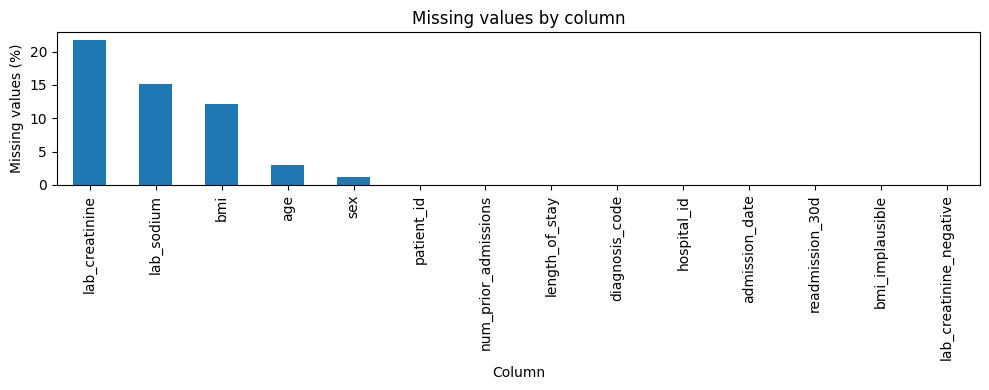

In [5]:
missing_report = missing_value_report(df)
ax = missing_report["missing_percentage"].plot(kind="bar", figsize=(10, 4))
ax.set_title("Missing values by column")
ax.set_xlabel("Column")
ax.set_ylabel("Missing values (%)")
plt.tight_layout()
plt.show()

## Target Rate by Hospital

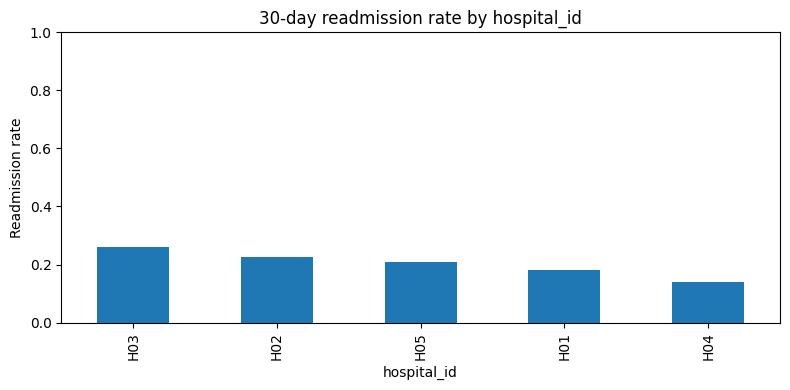

In [6]:
plot_target_rate_by(df, "hospital_id")

In [7]:
numeric_cols = [
    "age",
    "bmi",
    "num_prior_admissions",
    "length_of_stay",
    "lab_sodium",
    "lab_creatinine",
]
categorical_cols = ["sex", "diagnosis_code", "hospital_id"]

preprocessor = build_preprocessor(numeric_cols, categorical_cols)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na